In [1]:
import numpy as np
import torch
from intrinsics_dimension import twonn_pytorch
import os
import yaml
import numpy as np
import os
from scipy.linalg import svd
from functools import wraps
import matplotlib.pyplot as plt

In [2]:
def get_relative_depth(data):
    return np.arange(len(data))/len(data)

#### Сравниваем разные датасеты

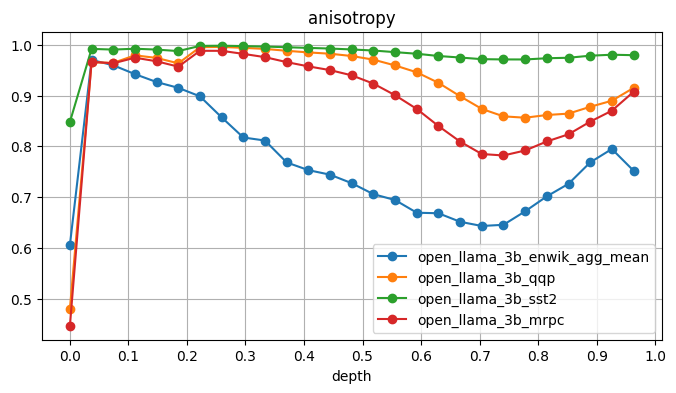

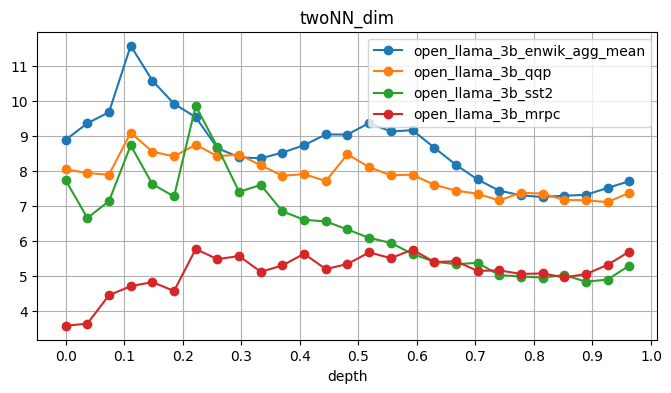

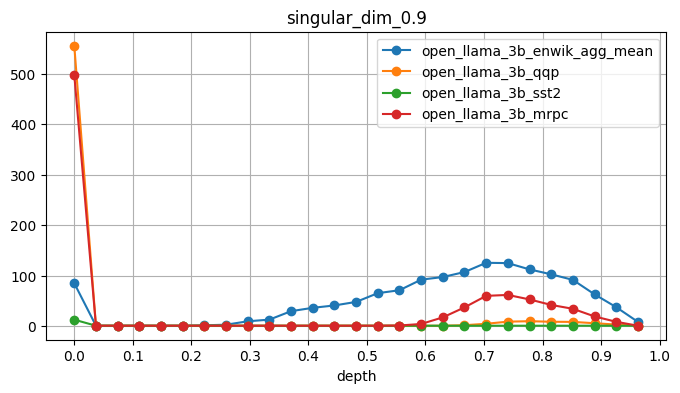

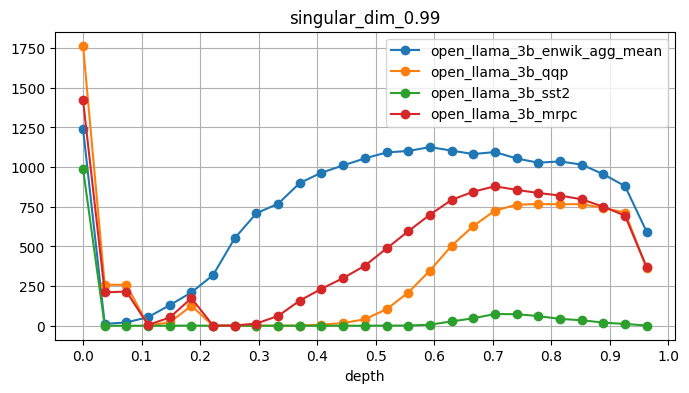

In [3]:
stat_names = [
    'anisotropy',
    'twoNN_dim',
    'singular_dim_0.9',
    'singular_dim_0.99',
]
names = [
    'open_llama_3b_enwik_agg_mean',
    'open_llama_3b_qqp',
    'open_llama_3b_sst2',
    'open_llama_3b_mrpc'
]
for stat_name in stat_names:
    fig, ax = plt.subplots(figsize = (8, 4))
    for name in names:
        with open(f'../all_stats/{name}.yaml', 'r') as f:
            data = yaml.safe_load(f)
            data = data[stat_name]
        ax.plot(get_relative_depth(data), data, label = name, marker = 'o')
    ax.set(title = stat_name,
        xlabel = 'depth')
    step = 0.1
    ax.set_xticks(np.arange(0, 1 + step, step))
    #ax.set_ylim(0, 20)
    step = 0.1
    ax.legend()
    ax.grid()
    plt.show()

#### Сравниваем mean vs last hidden на enwik/mrpc

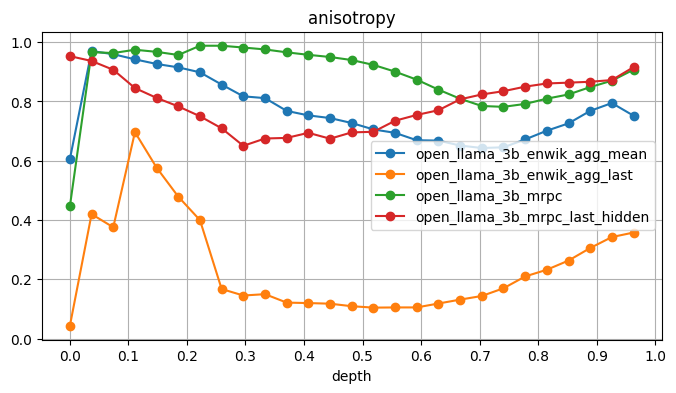

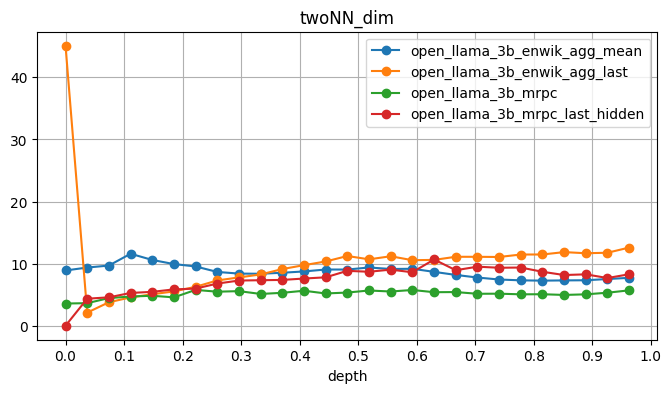

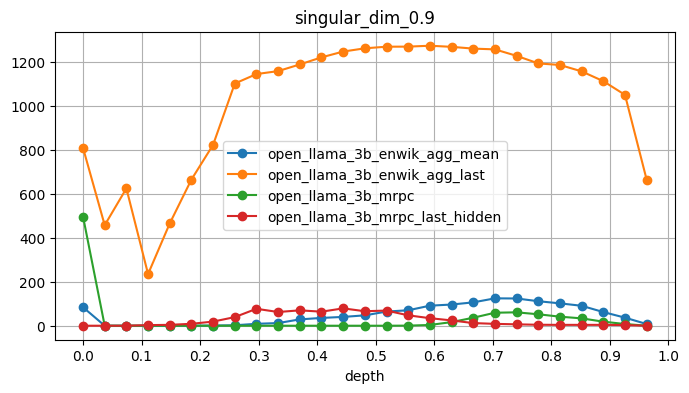

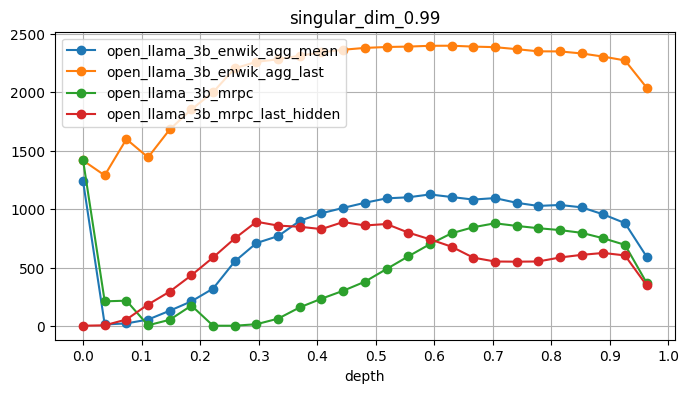

In [4]:
stat_names = [
    'anisotropy',
    'twoNN_dim',
    'singular_dim_0.9',
    'singular_dim_0.99',
]
names = [
    'open_llama_3b_enwik_agg_mean',
    'open_llama_3b_enwik_agg_last',
    'open_llama_3b_mrpc',
    'open_llama_3b_mrpc_last_hidden'
]
for stat_name in stat_names:
    fig, ax = plt.subplots(figsize = (8, 4))
    for name in names:
        with open(f'../all_stats/{name}.yaml', 'r') as f:
            data = yaml.safe_load(f)
            data = data[stat_name]
        ax.plot(get_relative_depth(data), data, label = name, marker = 'o')
    ax.set(title = stat_name,
        xlabel = 'depth')
    step = 0.1
    ax.set_xticks(np.arange(0, 1 + step, step))
    #ax.set_ylim(0, 20)
    step = 0.1
    ax.legend()
    ax.grid()
    plt.show()

In [11]:
def get_classif_stats(path, metric_name):
    with open(path, 'r') as f:
        data = yaml.safe_load(f)
    return [data[i][metric_name] for i in range(len(data))]

def get_dim_stats(path, metric_name):
    with open(path, 'r') as f:
        data = yaml.safe_load(f)
        data = data[metric_name]
    return data



#### Классификационные метрики:

In [12]:
import yaml
def show_classif_stats(path_to_stats : str, metrics_to_show = ['accuracy', 'roc_auc', 'f1_score']):
    fig, ax = plt.subplots(figsize = (8, 4))
    for metric in metrics_to_show:
        metric_arr = get_classif_stats(path_to_stats, metric)
        ax.plot(get_relative_depth(metric_arr), metric_arr, label = metric, marker = 'o')
    ax.set(title = path_to_stats,
        xlabel = 'depth')
    step = 0.1
    ax.set_xticks(np.arange(0, 1 + step, step))
    #ax.set_ylim(0, 20)
    step = 0.1
    ax.legend()
    ax.grid()
    plt.show()

##### Усредненные hidden'ы

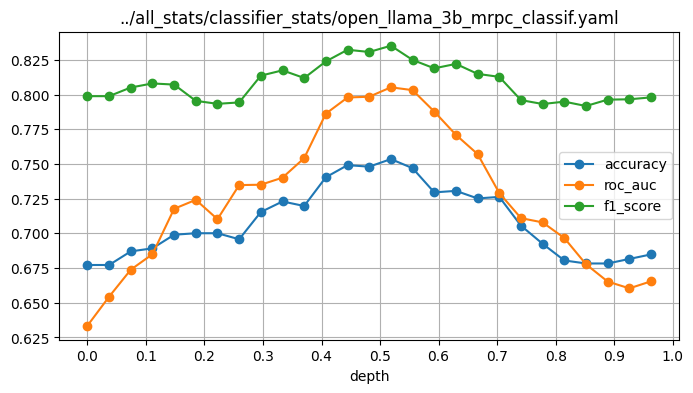

In [13]:
show_classif_stats('../all_stats/classifier_stats/open_llama_3b_mrpc_classif.yaml')

##### Последние hidden'ы

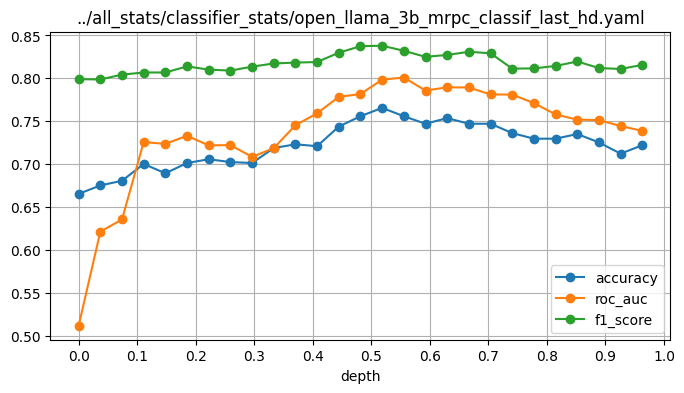

In [14]:
show_classif_stats('../all_stats/classifier_stats/open_llama_3b_mrpc_classif_last_hd.yaml')

##### roc_auc средние vs последние hidden'ы

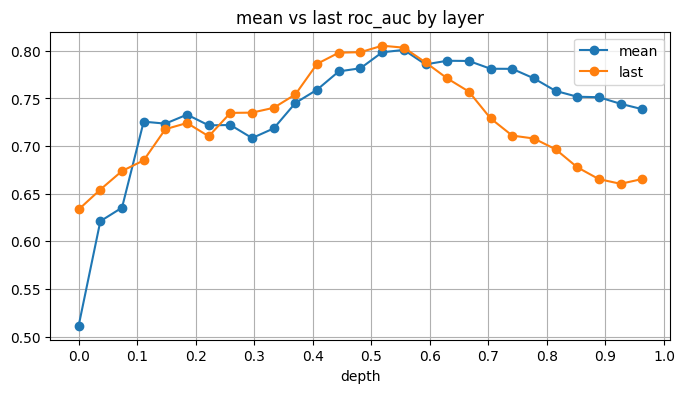

In [15]:
mean_hd_roc_auc = get_classif_stats('../all_stats/classifier_stats/open_llama_3b_mrpc_classif_last_hd.yaml', 'roc_auc')
last_hd_roc_auc = get_classif_stats('../all_stats/classifier_stats/open_llama_3b_mrpc_classif.yaml', 'roc_auc')
fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(get_relative_depth(mean_hd_roc_auc), mean_hd_roc_auc, label = 'mean', marker = 'o')
ax.plot(get_relative_depth(last_hd_roc_auc), last_hd_roc_auc, label = 'last', marker = 'o')
ax.set(title = 'mean vs last roc_auc by layer',
        xlabel = 'depth')
step = 0.1
ax.set_xticks(np.arange(0, 1 + step, step))
ax.legend()
ax.grid()
plt.show()


#### roc_auc тенденция по слоям для разных датасетов

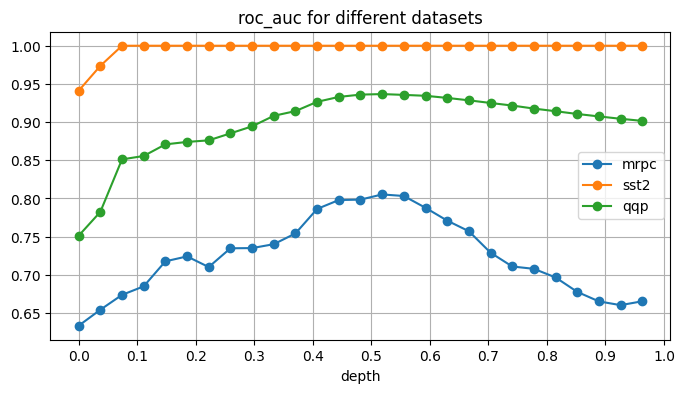

In [17]:
pathes = ['../all_stats/classifier_stats/open_llama_3b_mrpc_classif.yaml',
          '../all_stats/classifier_stats/open_llama_3b_sst2_classif.yaml',
          '../all_stats/classifier_stats/open_llama_3b_qqp_classif.yaml']
names = ['mrpc',
         'sst2',
         'qqp']
fig, ax = plt.subplots(figsize = (8, 4))
for path, name in zip(pathes, names):
    roc_auc = get_classif_stats(path, 'roc_auc')
    ax.plot(get_relative_depth(roc_auc), roc_auc, label = name, marker = 'o')
ax.set(title = 'roc_auc for different datasets',
        xlabel = 'depth')
step = 0.1
ax.set_xticks(np.arange(0, 1 + step, step))
ax.legend()
ax.grid()
plt.show()

#### dimention stats vs classifier stats

In [18]:
import seaborn as sns
all_stats = {}
for metric in ['accuracy', 'roc_auc', 'f1_score', 'recall']:
    all_stats[metric] = get_classif_stats('../all_stats/classifier_stats/open_llama_3b_mrpc_classif.yaml', metric)
for metric in stat_names:
    all_stats[metric] = get_dim_stats(f'../all_stats/open_llama_3b_mrpc.yaml', metric)

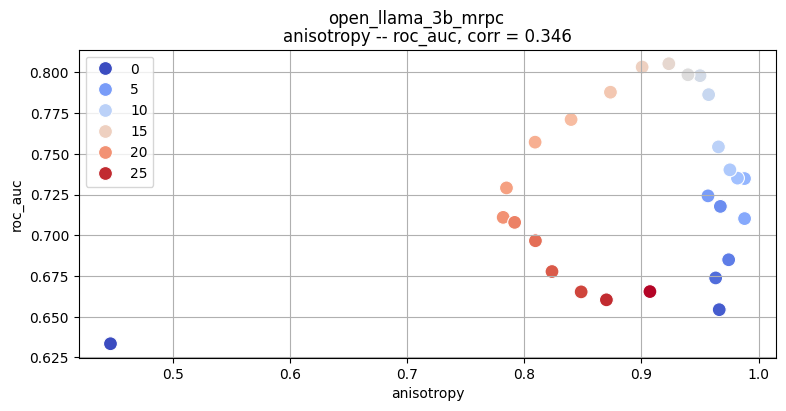

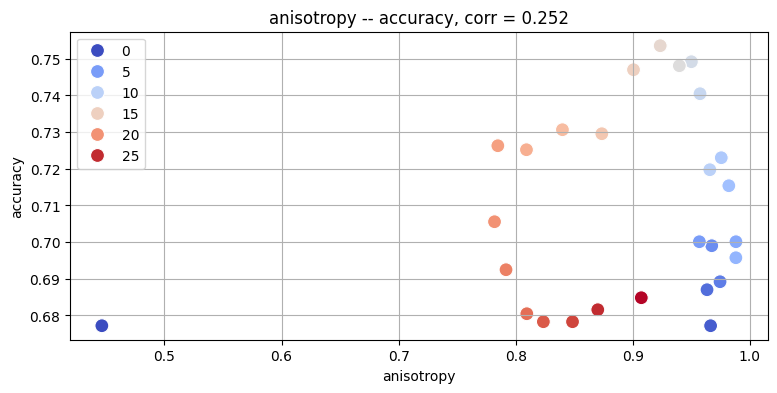

In [40]:
fig, ax = plt.subplots(figsize = (9, 4))
fig.suptitle('open_llama_3b_mrpc')

x_stat = 'anisotropy'
y_stat = 'roc_auc'
indices = np.arange(len(all_stats[x_stat]))
sns.scatterplot(all_stats, x = x_stat, y = y_stat, ax = ax, hue = indices, palette='coolwarm', s = 100)
corr = np.corrcoef(all_stats[x_stat], all_stats[y_stat])
ax.grid()
ax.set(
        title = f'{x_stat} -- {y_stat}, corr = {float(corr[0, 1]):.3f}'
)
plt.show()

fig, ax = plt.subplots(figsize = (9, 4))
x_stat = 'anisotropy'
y_stat = 'accuracy'
sns.scatterplot(all_stats, x = x_stat, y = y_stat, ax = ax, hue = indices, palette='coolwarm', s = 100)
corr = np.corrcoef(all_stats[x_stat], all_stats[y_stat])
ax.grid()
ax.set(
        title = f'{x_stat} -- {y_stat}, corr = {float(corr[0, 1]):.3f}'
)
plt.show()

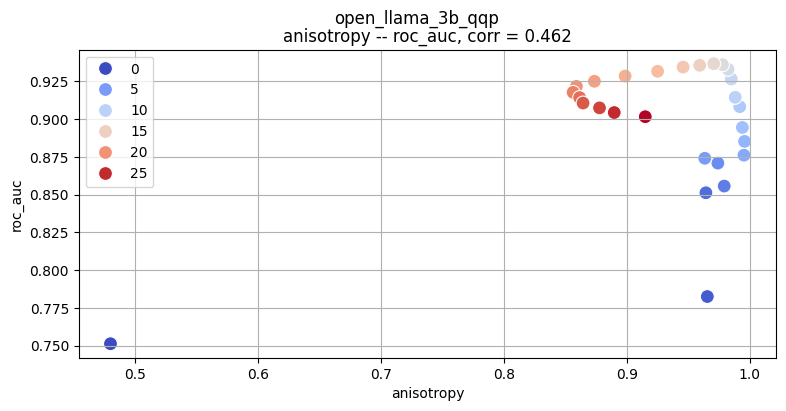

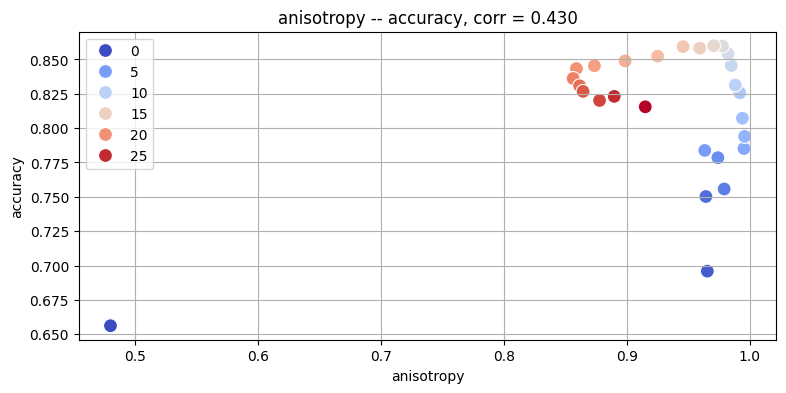

In [41]:
all_stats = {}
for metric in ['accuracy', 'roc_auc', 'f1_score', 'recall']:
    all_stats[metric] = get_classif_stats('../all_stats/classifier_stats/open_llama_3b_qqp_classif.yaml', metric)
for metric in stat_names:
    all_stats[metric] = get_dim_stats(f'../all_stats/open_llama_3b_qqp.yaml', metric)

fig, ax = plt.subplots(figsize = (9, 4))
fig.suptitle('open_llama_3b_qqp')

x_stat = 'anisotropy'
y_stat = 'roc_auc'
indices = np.arange(len(all_stats[x_stat]))
sns.scatterplot(all_stats, x = x_stat, y = y_stat, ax = ax, hue = indices, palette='coolwarm', s = 100)
corr = np.corrcoef(all_stats[x_stat], all_stats[y_stat])
ax.grid()
ax.set(
        title = f'{x_stat} -- {y_stat}, corr = {float(corr[0, 1]):.3f}'
)
plt.show()

fig, ax = plt.subplots(figsize = (9, 4))
x_stat = 'anisotropy'
y_stat = 'accuracy'
sns.scatterplot(all_stats, x = x_stat, y = y_stat, ax = ax, hue = indices, palette='coolwarm', s = 100)
corr = np.corrcoef(all_stats[x_stat], all_stats[y_stat])
ax.grid()
ax.set(
        title = f'{x_stat} -- {y_stat}, corr = {float(corr[0, 1]):.3f}'
)
plt.show()

#### Сравниваем разные модели (2)

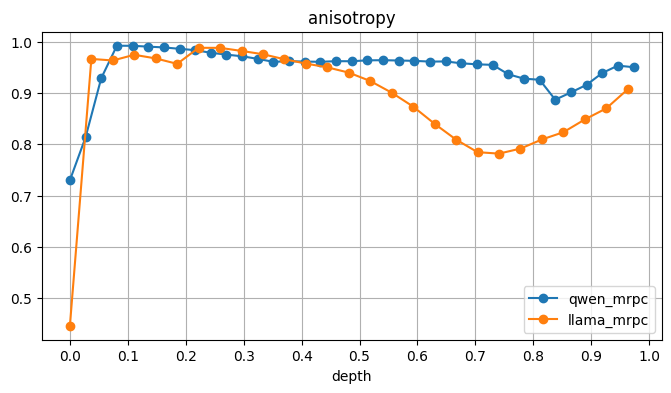

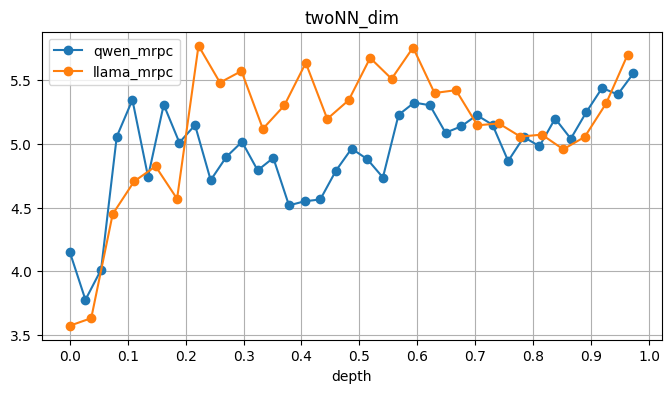

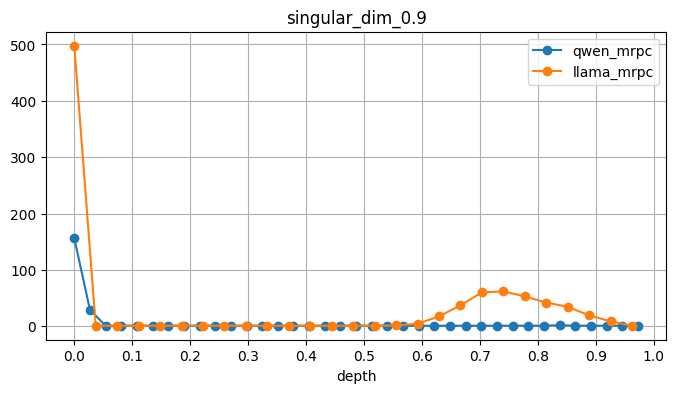

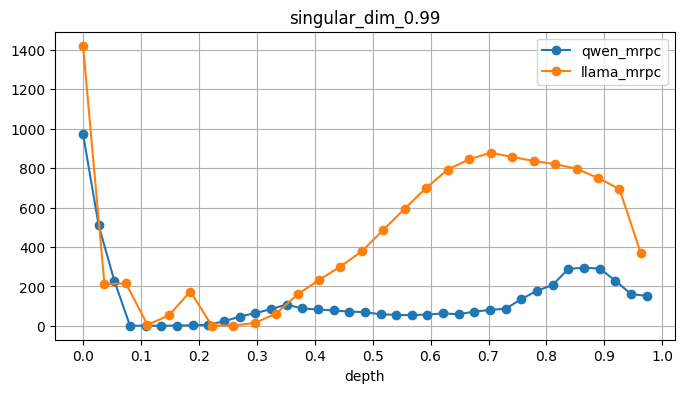

In [ ]:
pathes = ['../all_stats/open_qwen2.5-3b_mrpc.yaml',
          '../all_stats/open_llama_3b_mrpc.yaml']
names = ['qwen_mrpc',
         'llama_mrpc']
stat_names = [
    'anisotropy',
    'twoNN_dim',
    'singular_dim_0.9',
    'singular_dim_0.99',
]
for stat in stat_names:
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.set(title = f'{stat}',
        xlabel = 'depth')
    for path, name in zip(pathes, names):
        stat_arr = get_dim_stats(path, stat)
        ax.plot(get_relative_depth(stat_arr), stat_arr, label = name, marker = 'o')
    step = 0.1
    ax.grid(visible = True)
    ax.set_xticks(np.arange(0, 1 + step, step))
    ax.legend()
    plt.show()

#### Anisotropy vs roc_auc

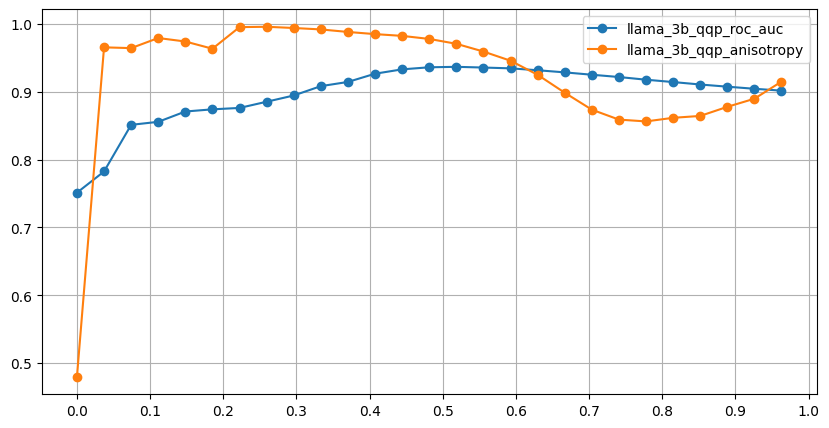

In [39]:
classif_pathes = ['../all_stats/classifier_stats/open_llama_3b_qqp_classif.yaml']
                  #'../all_stats/classifier_stats/open_llama_3b_mrpc_classif.yaml']
classif_names = ['llama_3b_qqp_roc_auc']#, 'llama_3b_mrpc_roc_auc']
dim_pathes = [
    '../all_stats/open_llama_3b_qqp.yaml',
#    '../all_stats/open_llama_3b_mrpc.yaml'
]
dim_names = ['llama_3b_qqp_anisotropy', 
            # 'llama_3b_mrpc_anisotropy'
             ]

fig, ax = plt.subplots(figsize = (10, 5))
for path, name in zip(classif_pathes, classif_names):
    metric = get_classif_stats(path, 'roc_auc')
    ax.plot(get_relative_depth(metric), metric, marker = 'o', label = name)

for path, name in zip(dim_pathes, dim_names):
    metric = get_dim_stats(path, 'anisotropy')
    ax.plot(get_relative_depth(metric), metric, marker = 'o', label = name)
step = 0.1
ax.grid(visible = True)
ax.set_xticks(np.arange(0, 1 + step, step))
ax.legend()
plt.show()

### Размерности

In [19]:
with open('all_stats/openLlama3B_MRPC.yaml', 'r') as f:
    llama_stats = yaml.safe_load(f)

with open('all_stats/qwen2.5-3B_MRPC.yaml', 'r') as f:
    qwen_stats = yaml.safe_load(f)
    
with open('all_stats/bloom-2B5.yaml', 'r') as f:
    bloom_2b_stats = yaml.safe_load(f)

with open('all_stats/bloom-1b1.yaml', 'r') as f:
    bloom_1b_stats = yaml.safe_load(f)
    
with open('all_stats/bloom-560m.yaml', 'r') as f:
    bloom_560m_stats = yaml.safe_load(f)

with open('all_stats/bloom-7B1.yaml', 'r') as f:
    bloom_7b_stats = yaml.safe_load(f)

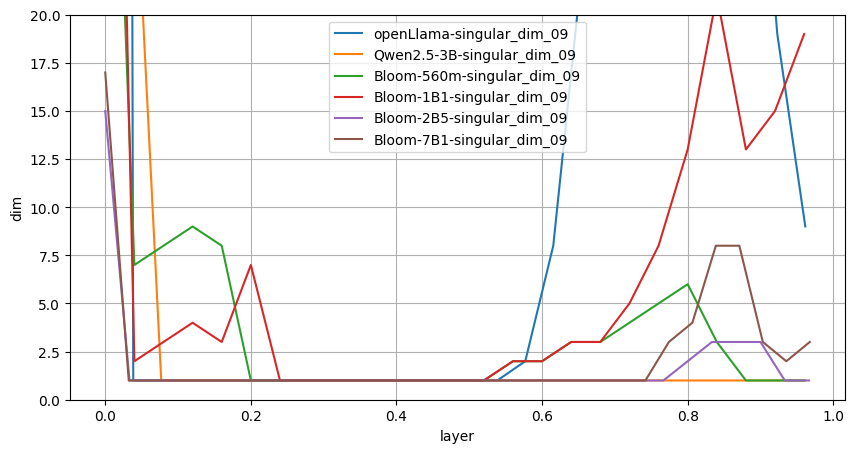

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10, 5))

for stats, label in zip([llama_stats, qwen_stats, bloom_560m_stats, bloom_1b_stats, bloom_2b_stats, bloom_7b_stats], 
                        ['openLlama', 'Qwen2.5-3B', 'Bloom-560m', 'Bloom-1B1', 'Bloom-2B5', 'Bloom-7B1']):
    ax.plot(get_relative_depth(stats['twoNN_dim']), stats['singular_dim_09'], label = f'{label}-singular_dim_09')

ax.set(
    xlabel = 'layer',
    ylabel = 'dim'
)
#ax.set_xticks(np.arange(26))
ax.grid()
ax.set_ylim(top = 20, bottom = 0)
ax.legend()
plt.show()

NameError: name 'llama_stats' is not defined

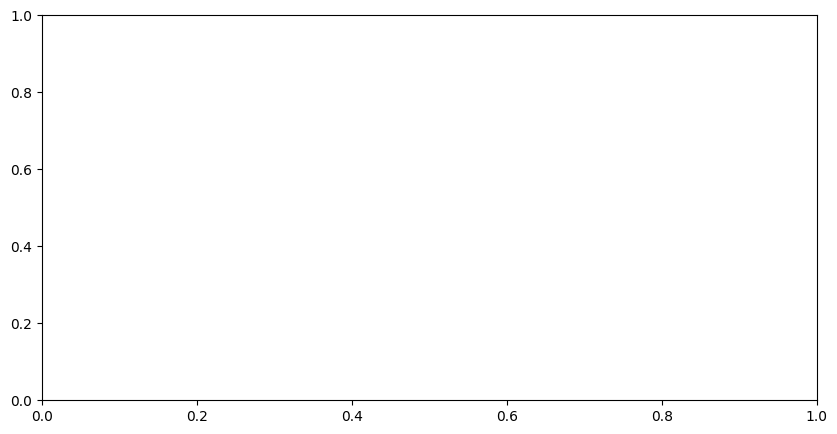

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10, 5))
for stats, label in zip([llama_stats, qwen_stats, bloom_560m_stats, bloom_1b_stats, bloom_2b_stats, bloom_7b_stats], 
                        ['openLlama', 'Qwen2.5-3B', 'Bloom-560m', 'Bloom-1B1', 'Bloom-2B5', 'Bloom-7B1']):
    ax.plot(get_relative_depth(stats['twoNN_dim']), stats['twoNN_dim'], label = f'{label}-twoNN_dim')
ax.set(
    xlabel = 'layer',
    ylabel = 'dim'
)
#ax.set_xticks(np.arange(26))
ax.grid()
ax.legend()
plt.show()

# MRPC
# sentence 1: .....

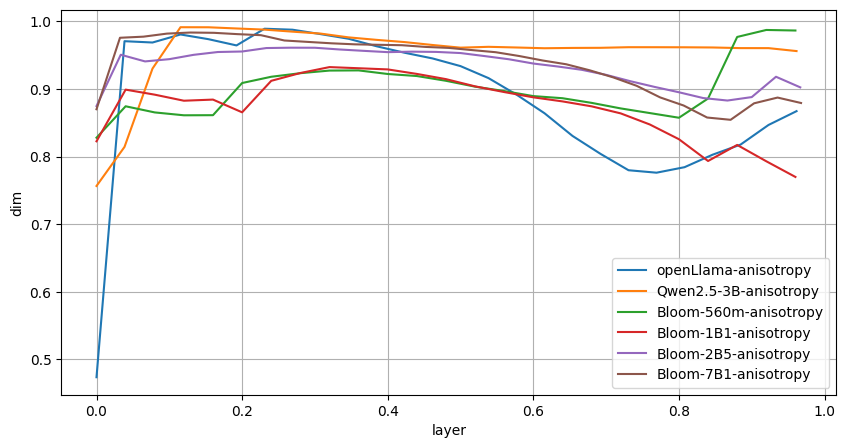

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10, 5))
for stats, label in zip([llama_stats, qwen_stats, bloom_560m_stats, bloom_1b_stats, bloom_2b_stats, bloom_7b_stats], 
                        ['openLlama', 'Qwen2.5-3B', 'Bloom-560m', 'Bloom-1B1', 'Bloom-2B5', 'Bloom-7B1']):
    ax.plot(get_relative_depth(stats['anisotropy']), stats['anisotropy'], label = f'{label}-anisotropy')
ax.set(
    xlabel = 'layer',
    ylabel = 'dim'
)
#ax.set_xticks(np.arange(26))
ax.grid()
ax.legend()
plt.show()